# 🤖 SuperStore Return Prediction — Machine Learning

## End-to-End Classification Modeling

This notebook develops an end-to-end machine-learning workflow for predicting
`Return_Flag` from the existing feature-engineered SuperStore dataset.

### Objectives
- Validate the ML dataset and target
- Review identifiers and possible leakage
- Create a stratified train/test split
- Build leakage-aware preprocessing
- Train multiple classification algorithms
- Compare Accuracy, Precision, Recall, F1 and ROC-AUC
- Select the best model primarily by F1 Score
- Evaluate the selected model
- Generate predictions and probabilities
- Export predictions, model comparison and model artifacts

> **Responsible AI:** model metrics and feature importance represent predictive
> evidence and should not be interpreted as causal conclusions.

## 📌 Project Position

This is **Notebook 05** in the SuperStore analytics project.

Earlier notebooks cover data inspection, cleaning, feature engineering,
business/statistical analysis, SQL analysis and Plotly business insights.

This notebook therefore focuses on **machine-learning prediction**.

**Target:** `Return_Flag`  
**Problem:** Binary Classification  
**Primary selection metric:** F1 Score

In [1]:
# ================================================================
# 01. IMPORT LIBRARIES
# ================================================================

import os
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## ⚙️ Configuration

The notebook uses the existing feature-engineered CSV from the project root.

In [2]:
# ================================================================
# 02. PROJECT CONFIGURATION
# ================================================================

DATA_PATH = "SuperStore_Feature_Engineered.csv"
TARGET = "Return_Flag"

RANDOM_STATE = 42
TEST_SIZE = 0.20

MODEL_DIR = "saved_models"
OUTPUT_DIR = "outputs"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Data path   :", DATA_PATH)
print("Target      :", TARGET)
print("Test size   :", TEST_SIZE)
print("Random state:", RANDOM_STATE)

Data path   : SuperStore_Feature_Engineered.csv
Target      : Return_Flag
Test size   : 0.2
Random state: 42


## 📂 Load Feature-Engineered Dataset

No synthetic data is created. The ML workflow uses the existing
`SuperStore_Feature_Engineered.csv`.

In [3]:
# ================================================================
# 03. LOAD DATASET
# ================================================================

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        "Run this notebook from the project root or update DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

display(df.head())

Dataset loaded successfully.
Rows    : 5,901
Columns : 54


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Region,Product_ID,Category,Sub-Category,Product_Name,Sales,Quantity,Profit,Returns,Payment_Mode,Order_Year,Order_Quarter,Order_Month,Order_Month_Name,Order_Day,Order_Day_Name,Shipping_Days,Sales_Per_Unit,Profit_Per_Unit,Profit_Margin,Customer_Order_Count,Customer_Total_Sales,Customer_Total_Profit,Product_Order_Count,Product_Total_Sales,Product_Total_Profit,Product_Total_Quantity,Product_Profit_Margin,Region_Total_Sales,Region_Total_Profit,State_Total_Sales,State_Total_Profit,City_Total_Sales,City_Total_Profit,Segment_Total_Sales,Segment_Total_Profit,Category_Total_Sales,Category_Total_Profit,SubCategory_Total_Sales,SubCategory_Total_Profit,ShipMode_Order_Count,PaymentMode_Order_Count,Return_Flag
0,4918,CA-2019-160304,2019-01-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.2668,No,Online,2019.0,1.0,1.0,January,1.0,Tuesday,181.0,73.94,28.2668,38.229375,5,1118.886,86.5160,7,1444.5238,1.0162,27,0.070348,450234.6660,53400.4243,16090.1030,3860.6173,479.8600,133.8078,509743.1262,57805.7991,451508.6452,10006.6112,57577.6862,-342.8883,1773,1562,0
1,4919,CA-2019-160304,2019-02-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.2668,No,Online,2019.0,1.0,2.0,February,1.0,Friday,150.0,57.98,12.7556,22.000000,5,1118.886,86.5160,7,1444.5238,1.0162,27,0.070348,450234.6660,53400.4243,16090.1030,3860.6173,479.8600,133.8078,509743.1262,57805.7991,451508.6452,10006.6112,57577.6862,-342.8883,1773,1562,0
2,4920,CA-2019-160304,2019-02-01,2019-07-01,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,TEC-PH-10000455,Technology,Phones,GE 30522EE2,231.98,2,67.2742,No,Cards,2019.0,1.0,2.0,February,1.0,Friday,150.0,115.99,33.6371,29.000000,5,1118.886,86.5160,2,599.9500,168.1855,5,28.033253,450234.6660,53400.4243,16090.1030,3860.6173,479.8600,133.8078,509743.1262,57805.7991,470587.9910,90458.2486,196563.5460,22308.9179,1773,985,0
3,3074,CA-2019-125206,2019-03-01,2019-05-01,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,California,West,OFF-ST-10003692,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.46,2,28.6150,No,Online,2019.0,1.0,3.0,March,1.0,Friday,61.0,57.23,14.3075,25.000000,4,2668.932,-99.8899,3,728.5300,114.4600,12,15.711089,522441.0520,67859.9582,335190.2560,49372.1750,120017.4405,19174.9301,753002.1291,81338.5875,643707.6870,74797.2461,150341.3180,13607.0875,499,1562,0
4,8604,US-2019-116365,2019-03-01,2019-08-01,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,Texas,Central,TEC-AC-10002217,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.08,2,-5.2640,No,Online,2019.0,1.0,3.0,March,1.0,Friday,153.0,15.04,-2.6320,-17.500000,3,2478.724,145.0254,4,345.6000,1.5040,18,0.435185,341007.5242,27450.0071,116261.9302,-14078.1598,6085.8710,-23.1982,509743.1262,57805.7991,470587.9910,90458.2486,122301.0860,25336.6455,1773,1562,0


## 🔎 Dataset Validation

Validate shape, data types, missing values and duplicates before modeling.

In [4]:
# ================================================================
# 04. DATASET VALIDATION
# ================================================================

print("Dataset shape:", df.shape)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape: (5901, 54)

Data types:


,dtype
Row_ID,int64
Order_ID,str
Order_Date,str
Ship_Date,str
Ship_Mode,str
Customer_ID,str
Customer_Name,str
Segment,str
Country,str
City,str



Missing values:


,missing_count
Shipping_Days,4216
Ship_Date,3550
Order_Year,3491
Order_Month_Name,3491
Order_Quarter,3491
Order_Date,3491
Order_Month,3491
Order_Day,3491
Order_Day_Name,3491



Duplicate rows:
0


## 🎯 Target Validation

The target must exist and contain exactly two classes for this binary
classification workflow.

In [5]:
# ================================================================
# 05. TARGET VALIDATION
# ================================================================

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' was not found.")

target_values = df[TARGET].dropna().unique()

print("Target:", TARGET)
print("Unique target values:", target_values)

display(
    df[TARGET]
    .value_counts(dropna=False)
    .to_frame("count")
)

if len(target_values) != 2:
    raise ValueError(
        f"Expected 2 target classes, found {len(target_values)}: "
        f"{target_values}"
    )

Target: Return_Flag
Unique target values: [0 1]


,count
Return_Flag,
0,5614
1,287


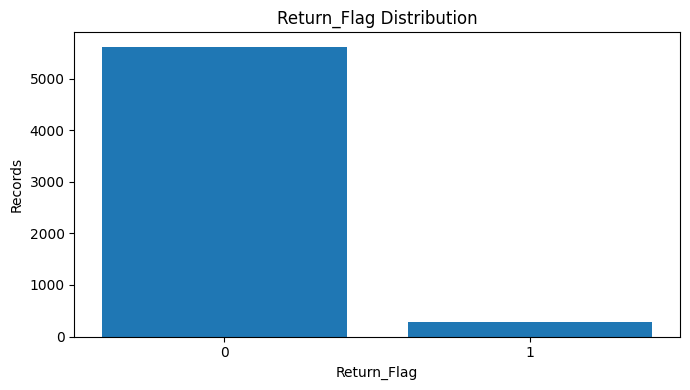

,percentage
Return_Flag,
0,95.14
1,4.86


In [6]:
# ================================================================
# TARGET DISTRIBUTION
# ================================================================

target_counts = df[TARGET].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("Return_Flag Distribution")
plt.xlabel("Return_Flag")
plt.ylabel("Records")
plt.tight_layout()
plt.show()

display(
    df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .sort_index()
    .to_frame("percentage")
)

## 🧩 Feature / Target Separation

The target is removed from the predictor matrix so the model cannot directly
receive the answer.

In [7]:
# ================================================================
# 06. FEATURE / TARGET SEPARATION
# ================================================================

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

print("Feature matrix X:", X.shape)
print("Target vector y :", y.shape)
print("Target classes  :", sorted(y.dropna().unique()))

Feature matrix X: (5901, 53)
Target vector y : (5901,)
Target classes  : [np.int64(0), np.int64(1)]


## 🛡️ Identifier & Leakage Review

Identifier-like columns are flagged for inspection. They are not automatically
removed because the correct decision depends on the feature-engineering logic
used earlier in the project.

In [8]:
# ================================================================
# 07. IDENTIFIER / LEAKAGE CANDIDATE REVIEW
# ================================================================

id_keywords = [
    "id", "row_id", "order_number",
    "order_id", "customer_id", "product_id"
]

id_candidates = [
    col for col in X.columns
    if any(keyword in col.lower() for keyword in id_keywords)
]

print("Potential identifier columns:")
print(id_candidates if id_candidates else "None detected")

feature_info = pd.DataFrame({
    "Feature": X.columns,
    "Data_Type": X.dtypes.astype(str).values,
    "Missing": X.isna().sum().values,
    "Unique": X.nunique(dropna=True).values
})

display(feature_info)

Potential identifier columns:
['Row_ID', 'Order_ID', 'Customer_ID', 'Product_ID']


,Feature,Data_Type,Missing,Unique
0,Row_ID,int64,0,5900
1,Order_ID,str,0,3003
2,Order_Date,str,3491,252
3,Ship_Date,str,3550,273
4,Ship_Mode,str,0,4
5,Customer_ID,str,0,773
6,Customer_Name,str,0,773
7,Segment,str,0,3
8,Country,str,0,1
9,City,str,0,452


## ✂️ Train / Test Split

A stratified split preserves target-class proportions in both partitions.
The test set remains unseen during model fitting.

In [9]:
# ================================================================
# 08. TRAIN / TEST SPLIT
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

print("\nTraining target distribution:")
display(
    y_train.value_counts(normalize=True)
    .mul(100).round(2).sort_index()
    .to_frame("percentage")
)

print("\nTesting target distribution:")
display(
    y_test.value_counts(normalize=True)
    .mul(100).round(2).sort_index()
    .to_frame("percentage")
)

Training data: (4720, 53)
Testing data : (1181, 53)

Training target distribution:


,percentage
Return_Flag,
0,95.13
1,4.87



Testing target distribution:


,percentage
Return_Flag,
0,95.17
1,4.83


## ⚙️ Preprocessing Pipeline

Numerical columns use median imputation and scaling.

Categorical columns use most-frequent imputation and one-hot encoding.

The transformations are placed inside the model pipeline so they are fitted
only on training data and reused consistently at prediction time.

In [10]:
# ================================================================
# 09. FEATURE TYPE DETECTION
# ================================================================

numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numerical features :", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nNumerical:")
print(numeric_features)

print("\nCategorical:")
print(categorical_features)

Numerical features : 34
Categorical features: 19

Numerical:
['Row_ID', 'Sales', 'Quantity', 'Profit', 'Order_Year', 'Order_Quarter', 'Order_Month', 'Order_Day', 'Shipping_Days', 'Sales_Per_Unit', 'Profit_Per_Unit', 'Profit_Margin', 'Customer_Order_Count', 'Customer_Total_Sales', 'Customer_Total_Profit', 'Product_Order_Count', 'Product_Total_Sales', 'Product_Total_Profit', 'Product_Total_Quantity', 'Product_Profit_Margin', 'Region_Total_Sales', 'Region_Total_Profit', 'State_Total_Sales', 'State_Total_Profit', 'City_Total_Sales', 'City_Total_Profit', 'Segment_Total_Sales', 'Segment_Total_Profit', 'Category_Total_Sales', 'Category_Total_Profit', 'SubCategory_Total_Sales', 'SubCategory_Total_Profit', 'ShipMode_Order_Count', 'PaymentMode_Order_Count']

Categorical:
['Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product_ID', 'Category', 'Sub-Category', 'Product_Name', 'Returns', 'Payment_Mode', 'Order_Mo

In [11]:
# ================================================================
# PREPROCESSOR
# ================================================================

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessor created successfully.")

Preprocessor created successfully.


## 🧪 Baseline Model

The majority-class baseline provides a simple reference point.

In [12]:
# ================================================================
# 10. BASELINE MODEL
# ================================================================

positive_class = sorted(y.dropna().unique())[-1]

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    pos_label=positive_class,
    zero_division=0
)

print(f"Baseline F1: {baseline_f1:.4f}")

Baseline F1: 0.0000


## 🤖 Candidate Classification Models

Multiple algorithms are evaluated rather than relying on one model.

In [13]:
# ================================================================
# 11. CLASSIFICATION MODELS
# ================================================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

for name in models:
    print("-", name)

- Logistic Regression
- Random Forest
- Extra Trees
- Gradient Boosting


## 🏋️ Train & Evaluate Models

Metrics:

- Accuracy
- Precision
- Recall
- F1
- ROC-AUC

**F1 is the primary selection metric.**

In [14]:
# ================================================================
# 12. MODEL TRAINING & EVALUATION
# ================================================================

trained_models = []
results = []

for model_name, model in models.items():

    print(f"Training: {model_name}")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred,
            pos_label=positive_class,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred,
            pos_label=positive_class,
            zero_division=0
        ),
        "F1": f1_score(
            y_test, y_pred,
            pos_label=positive_class,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

    trained_models.append((model_name, pipeline))

results_df = (
    pd.DataFrame(results)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

Training: Logistic Regression
Training: Random Forest
Training: Extra Trees
Training: Gradient Boosting


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000
1,Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000
2,Extra Trees,0.9975,1.0000,0.9474,0.9730,1.0000
3,Random Forest,0.9949,1.0000,0.8947,0.9444,1.0000


## 🏆 Model Comparison

Models are ranked by F1 Score. Supporting metrics remain visible for a complete
evaluation context.

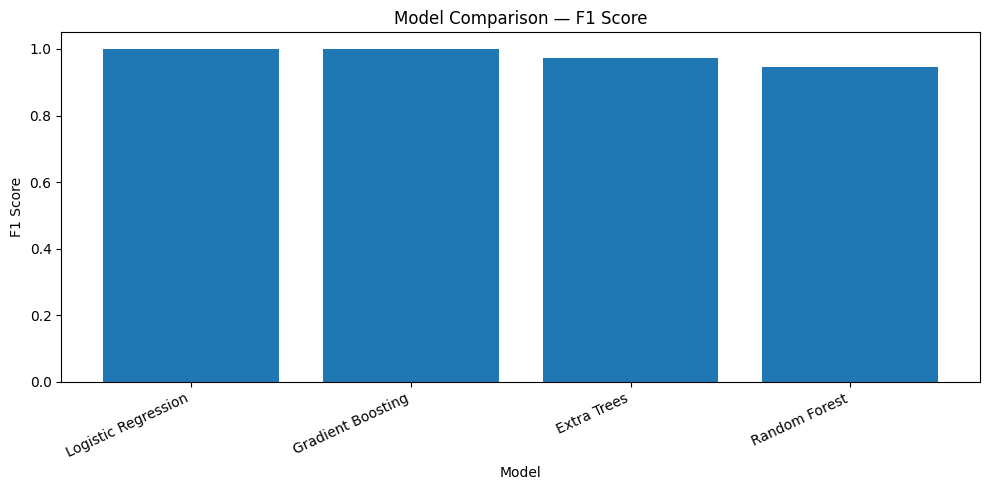

In [15]:
# ================================================================
# 13. F1 COMPARISON
# ================================================================

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["F1"])
plt.title("Model Comparison — F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 🥇 Select Best Model

The highest-F1 candidate is selected.

In [16]:
# ================================================================
# 14. BEST MODEL
# ================================================================

best_model_name = results_df.iloc[0]["Model"]
best_model = dict(trained_models)[best_model_name]
best_row = results_df.iloc[0]

print("Selected model:", best_model_name)
print(f"Accuracy : {best_row['Accuracy']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall   : {best_row['Recall']:.4f}")
print(f"F1       : {best_row['F1']:.4f}")
print(f"ROC-AUC  : {best_row['ROC-AUC']:.4f}")

Selected model: Logistic Regression
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1       : 1.0000
ROC-AUC  : 1.0000


## 📋 Detailed Evaluation

In [17]:
# ================================================================
# 15. CLASSIFICATION REPORT
# ================================================================

best_pred = best_model.predict(X_test)
best_proba = best_model.predict_proba(X_test)[:, 1]

print(
    classification_report(
        y_test,
        best_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1124
           1       1.00      1.00      1.00        57

    accuracy                           1.00      1181
   macro avg       1.00      1.00      1.00      1181
weighted avg       1.00      1.00      1.00      1181



## 🔲 Confusion Matrix

[[1124    0]
 [   0   57]]


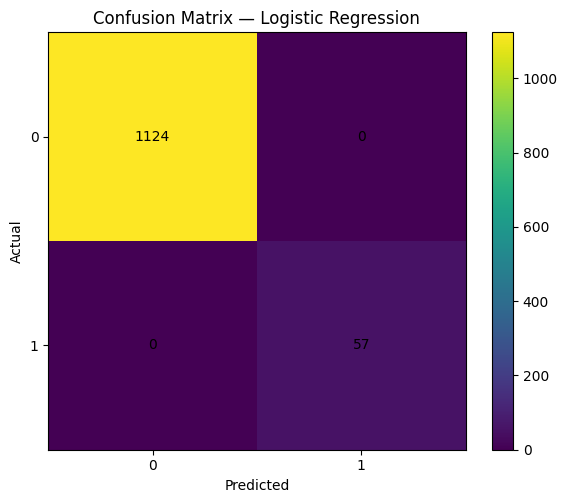

In [18]:
# ================================================================
# 16. CONFUSION MATRIX
# ================================================================

labels = sorted(y.dropna().unique())

cm = confusion_matrix(y_test, best_pred, labels=labels)

print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.xticks(range(len(labels)), [str(x) for x in labels])
plt.yticks(range(len(labels)), [str(x) for x in labels])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

## 📈 ROC Curve

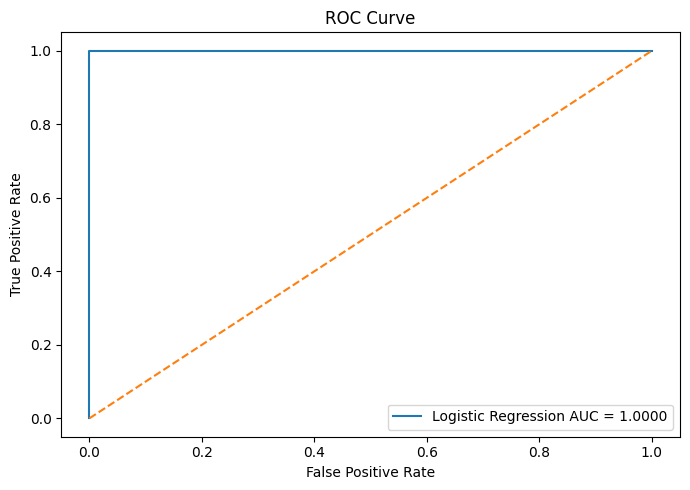

In [19]:
# ================================================================
# 17. ROC CURVE
# ================================================================

fpr, tpr, _ = roc_curve(
    y_test,
    best_proba,
    pos_label=positive_class
)

auc_value = roc_auc_score(y_test, best_proba)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"{best_model_name} AUC = {auc_value:.4f}"
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

## 💡 Predictive Feature Interpretation

For tree-based models, feature importance can be extracted after preprocessing.
These values describe predictive association, not causation.

In [20]:
# ================================================================
# 18. FEATURE IMPORTANCE
# ================================================================

model_estimator = best_model.named_steps["model"]

if hasattr(model_estimator, "feature_importances_"):

    fitted_preprocessor = best_model.named_steps["preprocessor"]
    feature_names = fitted_preprocessor.get_feature_names_out()

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model_estimator.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(importance_df.head(20))

    plot_df = importance_df.head(20).sort_values("Importance")

    plt.figure(figsize=(9, 7))
    plt.barh(plot_df["Feature"], plot_df["Importance"])
    plt.title(f"Top 20 Predictive Features — {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

else:
    importance_df = pd.DataFrame()
    print("Selected model does not expose feature_importances_.")

Selected model does not expose feature_importances_.


## 🎯 Generate Test-Set Predictions

The output contains the actual class, predicted class, probability and confidence.

In [21]:
# ================================================================
# 19. TEST-SET PREDICTIONS
# ================================================================

prediction_output = X_test.copy()

prediction_output["Actual_Return_Flag"] = y_test.values
prediction_output["Predicted_Return_Flag"] = best_pred
prediction_output["Return_Probability"] = best_proba

prediction_output["Prediction_Confidence"] = (
    np.maximum(best_proba, 1 - best_proba) * 100
)

display(prediction_output.head(20))

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Region,Product_ID,Category,Sub-Category,Product_Name,Sales,Quantity,Profit,Returns,Payment_Mode,Order_Year,Order_Quarter,Order_Month,Order_Month_Name,Order_Day,Order_Day_Name,Shipping_Days,Sales_Per_Unit,Profit_Per_Unit,Profit_Margin,Customer_Order_Count,Customer_Total_Sales,Customer_Total_Profit,Product_Order_Count,Product_Total_Sales,Product_Total_Profit,Product_Total_Quantity,Product_Profit_Margin,Region_Total_Sales,Region_Total_Profit,State_Total_Sales,State_Total_Profit,City_Total_Sales,City_Total_Profit,Segment_Total_Sales,Segment_Total_Profit,Category_Total_Sales,Category_Total_Profit,SubCategory_Total_Sales,SubCategory_Total_Profit,ShipMode_Order_Count,PaymentMode_Order_Count,Actual_Return_Flag,Predicted_Return_Flag,Return_Probability,Prediction_Confidence
5327,8977,CA-2020-156622,NaN,NaN,First Class,JP-15460,Jennifer Patt,Corporate,United States,Dallas,Texas,Central,FUR-TA-10003008,Furniture,Tables,"Lesro Round Back Collection Coffee Table, End ...",162.785,1,-31.0335,No,Cards,NaN,NaN,NaN,NaN,NaN,NaN,NaN,162.785000,-31.0335,-19.064103,5,1754.213,318.0049,5,1209.240,-394.3080,8,-32.607919,341007.5242,27450.0071,116261.9302,-14078.1598,20019.1136,-1983.7422,509743.1262,57805.7991,451508.6452,10006.6112,119293.743,-11091.6365,499,985,0,0,0.003377,99.662302
954,1799,CA-2019-100965,2019-07-07,2019-11-07,Standard Class,RM-19375,Raymond Messe,Consumer,United States,San Jose,California,West,FUR-FU-10003039,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Grantwood Wall ...",215.650,5,73.3210,No,COD,2019.0,3.0,7.0,July,7.0,Sunday,123.0,43.130000,14.6642,34.000000,3,1471.730,358.3620,4,477.544,123.3518,9,25.830458,522441.0520,67859.9582,335190.2560,49372.1750,3733.9070,739.4290,753002.1291,81338.5875,451508.6452,10006.6112,92691.218,8034.4328,1773,1717,0,0,0.001196,99.880371
3373,5804,US-2020-106796,2020-12-05,NaN,Standard Class,JP-16135,Julie Prescott,Home Office,United States,Springfield,Ohio,East,OFF-AR-10003504,Office Supplies,Art,Newell 347,96.272,3,1.1556,No,COD,2020.0,4.0,12.0,December,5.0,Saturday,NaN,32.090667,0.3852,1.200349,7,4127.398,295.3620,4,429.752,21.0148,19,4.889983,450234.6660,53400.4243,68194.8600,-9339.4223,26563.2020,1508.6366,303059.0679,36117.7193,643707.6870,74797.2461,50762.976,3635.9257,1773,1717,0,0,0.000828,99.917208
814,8723,CA-2019-120824,2019-12-06,NaN,Second Class,AW-10930,Arthur Wiediger,Home Office,United States,Houston,Texas,Central,OFF-BI-10001525,Office Supplies,Binders,"Acco Pressboard Covers with Storage Hooks, 14 ...",1.524,2,-2.6670,No,COD,2019.0,4.0,12.0,December,6.0,Friday,NaN,0.762000,-1.3335,-175.000000,5,2642.824,-126.2294,5,297.241,-20.7645,21,-6.985746,341007.5242,27450.0071,116261.9302,-14078.1598,45159.5078,-7197.7160,303059.0679,36117.7193,643707.6870,74797.2461,174978.390,17885.3759,568,1717,0,0,0.000301,99.969946
4355,4625,CA-2020-147228,2020-09-09,NaN,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Columbia,Tennessee,South,OFF-ST-10000046,Office Supplies,Storage,Fellowes Super Stor/Drawer Files,292.480,2,-3.2310,No,Online,2020.0,3.0,9.0,September,9.0,Wednesday,NaN,146.240000,-1.6155,-1.104691,4,1473.056,201.2320,2,635.580,58.1580,4,9.150382,252121.0810,26551.7163,26288.3170,-3467.5906,13705.1480,2721.1764,753002.1291,81338.5875,643707.6870,74797.2461,150341.318,13607.0875,1773,1562,0,0,0.002585,99.741523
3291,9336,CA-2020-110198,2020-01-05,2020-02-05,First Class,AG-10900,Arthur Gainer,Consumer,United States,Coral Springs,Florida,South,OFF-LA-10004409,Office Supplies,Labels,Avery 492,215.608,2,1.4976,No,Online,2020.0,1.0,1.0,January,5.0,Sunday,31.0,107.804000,0.7488,0.694594,5,2223.810,180.3946,2,322.368,4.1472,4,1.286480,252121.0810,26551.7163,49914.9990,-227.7465,550.9600,-14.2200,753002.1291,81338.5875,643707.6870,74797.2461,19397.456,2937.2212,499,1562,0,0,0.001638,99.836221
1693,7666,US-2019-140158,2019-04-10,2019-08-10,Standard Class,DR-12940,Daniel 

## 💾 Export Prediction Results

In [22]:
# ================================================================
# 20. SAVE PREDICTIONS
# ================================================================

prediction_path = os.path.join(
    OUTPUT_DIR,
    "SuperStore_Return_Predictions.csv"
)

prediction_output.to_csv(prediction_path, index=False)

print("Saved:", prediction_path)
print("Rows:", len(prediction_output))

Saved: outputs\SuperStore_Return_Predictions.csv
Rows: 1181


## 📊 Export Model Comparison

In [23]:
# ================================================================
# 21. SAVE MODEL COMPARISON
# ================================================================

comparison_path = os.path.join(
    OUTPUT_DIR,
    "SuperStore_Model_Comparison.csv"
)

results_df.to_csv(comparison_path, index=False)

print("Saved:", comparison_path)

Saved: outputs\SuperStore_Model_Comparison.csv


## 📦 Save Final Reusable Model Pipeline

The complete preprocessing + model pipeline is saved together. This means the
same transformations can be reused when the Streamlit application performs
prediction.

In [24]:
# ================================================================
# 22. SAVE FINAL MODEL PIPELINE
# ================================================================

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "superstore_return_prediction_pipeline.joblib"
)

joblib.dump(
    best_model,
    MODEL_PATH,
    compress=3
)

model_size_mb = os.path.getsize(MODEL_PATH) / (1024 ** 2)

print("Saved model:", MODEL_PATH)
print(f"Model size : {model_size_mb:.2f} MB")

Saved model: saved_models\superstore_return_prediction_pipeline.joblib
Model size : 0.11 MB


## 🧾 Save Model Metadata

Metadata keeps the model-selection decision and evaluation information separate
from the binary model artifact.

In [25]:
# ================================================================
# 23. SAVE MODEL METADATA
# ================================================================

metadata = {
    "project": "SuperStore AI Intelligence Platform",
    "task": "Return_Flag Prediction",
    "problem_type": "Binary Classification",
    "target": TARGET,
    "selected_model": best_model_name,
    "selection_metric": "F1",
    "accuracy": float(best_row["Accuracy"]),
    "precision": float(best_row["Precision"]),
    "recall": float(best_row["Recall"]),
    "f1_score": float(best_row["F1"]),
    "roc_auc": float(best_row["ROC-AUC"]),
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "total_rows": int(len(df)),
    "training_rows": int(len(X_train)),
    "testing_rows": int(len(X_test)),
    "original_feature_count": int(X.shape[1]),
    "numeric_feature_count": int(len(numeric_features)),
    "categorical_feature_count": int(len(categorical_features)),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "identifier_candidates_reviewed": id_candidates
}

metadata_path = os.path.join(
    MODEL_DIR,
    "superstore_return_model_metadata.json"
)

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=4)

print("Saved metadata:", metadata_path)

Saved metadata: saved_models\superstore_return_model_metadata.json


## 🔁 Reload Test

Verify that the saved pipeline can be loaded and used for inference.

In [26]:
# ================================================================
# 24. RELOAD MODEL TEST
# ================================================================

reloaded_model = joblib.load(MODEL_PATH)

sample_predictions = reloaded_model.predict(
    X_test.head(10)
)

print("Reload successful.")
print("Sample predictions:", sample_predictions)

Reload successful.
Sample predictions: [0 0 0 0 0 0 0 0 0 0]


# ✅ Final ML Summary

The notebook now contains the complete core prediction workflow:

**Data → Validation → Split → Preprocessing → Baseline → Training → Comparison → Evaluation → Prediction → Model Artifact**

### Generated artifacts

```text
saved_models/
├── superstore_return_prediction_pipeline.joblib
└── superstore_return_model_metadata.json

outputs/
├── SuperStore_Return_Predictions.csv
└── SuperStore_Model_Comparison.csv
```

> The actual model scores and file sizes are generated only after the notebook
> is executed against the project's real dataset.

In [27]:
# ================================================================
# 25. FINAL SUMMARY
# ================================================================

print("=" * 72)
print("SUPERSTORE RETURN PREDICTION — FINAL SUMMARY")
print("=" * 72)

print(f"Dataset rows      : {len(df):,}")
print(f"Original features : {X.shape[1]}")
print(f"Target            : {TARGET}")
print(f"Training rows     : {len(X_train):,}")
print(f"Testing rows      : {len(X_test):,}")

print("-" * 72)

print(f"Selected model    : {best_model_name}")
print(f"Accuracy          : {best_row['Accuracy']:.4f}")
print(f"Precision         : {best_row['Precision']:.4f}")
print(f"Recall            : {best_row['Recall']:.4f}")
print(f"F1 Score          : {best_row['F1']:.4f}")
print(f"ROC-AUC           : {best_row['ROC-AUC']:.4f}")

print("-" * 72)

print("Model file        :", MODEL_PATH)
print("Metadata file     :", metadata_path)
print("Predictions file  :", prediction_path)
print("Comparison file   :", comparison_path)

print("=" * 72)

SUPERSTORE RETURN PREDICTION — FINAL SUMMARY
Dataset rows      : 5,901
Original features : 53
Target            : Return_Flag
Training rows     : 4,720
Testing rows      : 1,181
------------------------------------------------------------------------
Selected model    : Logistic Regression
Accuracy          : 1.0000
Precision         : 1.0000
Recall            : 1.0000
F1 Score          : 1.0000
ROC-AUC           : 1.0000
------------------------------------------------------------------------
Model file        : saved_models\superstore_return_prediction_pipeline.joblib
Metadata file     : saved_models\superstore_return_model_metadata.json
Predictions file  : outputs\SuperStore_Return_Predictions.csv
Comparison file   : outputs\SuperStore_Model_Comparison.csv
